# 50 Startups Dataset — EDA and Linear Regression

This notebook performs basic Exploratory Data Analysis (EDA) and Linear Regression on the 50 Startups dataset.

## 1. Import Libraries

Import the required Python libraries for data analysis and machine learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 2. Load the Dataset

Load the 50 Startups dataset and display the first few records.

In [2]:
df = pd.read_csv("50_Startups_dataset.csv")

df.head()

,Unnamed: 0,R&D Spend,Administration,Marketing Spend,State,Profit
0,0,165349.30,136897.90,471784.20,New York,192261.93
1,1,162597.80,151377.69,443898.63,California,191792.16
2,2,153441.61,101145.65,407934.64,Florida,191050.49
3,3,144372.51,118671.95,383199.72,New York,182902.09
4,4,142107.44,91391.87,366168.52,Florida,166188.04


## 3. Dataset Information

Check the size, columns, and data types of the dataset.

In [3]:
print("Shape:", df.shape)
df.info()

Shape: (50, 6)
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       50 non-null     int64  
 1   R&D Spend        50 non-null     float64
 2   Administration   50 non-null     float64
 3   Marketing Spend  50 non-null     float64
 4   State            50 non-null     str    
 5   Profit           50 non-null     float64
dtypes: float64(4), int64(1), str(1)
memory usage: 2.5 KB


## 4. Data Cleaning

Remove the unnecessary index column.

In [4]:
df = df.drop("Unnamed: 0", axis=1)

df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.30,136897.90,471784.20,New York,192261.93
1,162597.80,151377.69,443898.63,California,191792.16
2,153441.61,101145.65,407934.64,Florida,191050.49
3,144372.51,118671.95,383199.72,New York,182902.09
4,142107.44,91391.87,366168.52,Florida,166188.04


## 5. Check Missing Values

Check whether the dataset contains missing values.

In [5]:
print(df.isnull().sum())

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64


## 6. Check Duplicate Values

Check for duplicate records in the dataset.

In [6]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


## 7. Statistical Summary

Display the basic statistical summary of the numerical data.

In [7]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.715600,121344.739600,211025.197800,112012.739200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.100000,51283.240000,0.100000,14681.500000
25%,39936.470000,103730.975000,129300.232500,90139.002500
50%,73051.180000,122699.895000,212716.340000,107978.290000
75%,101602.900000,144842.280000,299469.185000,139766.077500
max,165349.300000,182645.660000,471784.200000,192261.930000


## 8. State Distribution

Check the number of startups in each state.

In [8]:
print(df["State"].value_counts())

State
New York      17
California    17
Florida       16
Name: count, dtype: int64


## 9. Exploratory Data Analysis

Analyze the relationship between startup spending and profit.

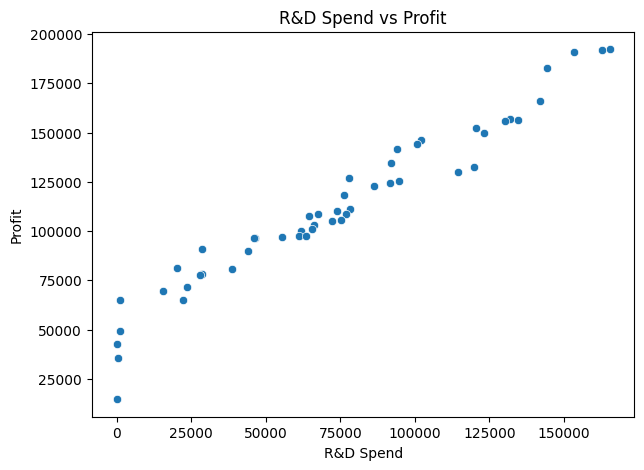

In [9]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x="R&D Spend", y="Profit")

plt.title("R&D Spend vs Profit")
plt.show()

## 10. Marketing Spend vs Profit

Analyze the relationship between marketing spending and profit.

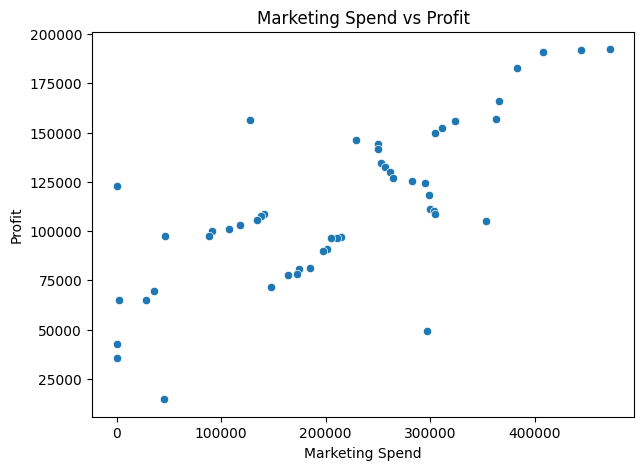

In [10]:
plt.figure(figsize=(7,5))

sns.scatterplot(data=df, x="Marketing Spend", y="Profit")

plt.title("Marketing Spend vs Profit")
plt.show()

## 11. Correlation Analysis

Calculate the correlation between numerical variables.

In [11]:
correlation = df.select_dtypes(include=np.number).corr()

print(correlation)

                 R&D Spend  Administration  Marketing Spend    Profit
R&D Spend         1.000000        0.241955         0.724248  0.972900
Administration    0.241955        1.000000        -0.032154  0.200717
Marketing Spend   0.724248       -0.032154         1.000000  0.747766
Profit            0.972900        0.200717         0.747766  1.000000


## 12. Correlation Heatmap

Visualize the correlations between numerical variables.

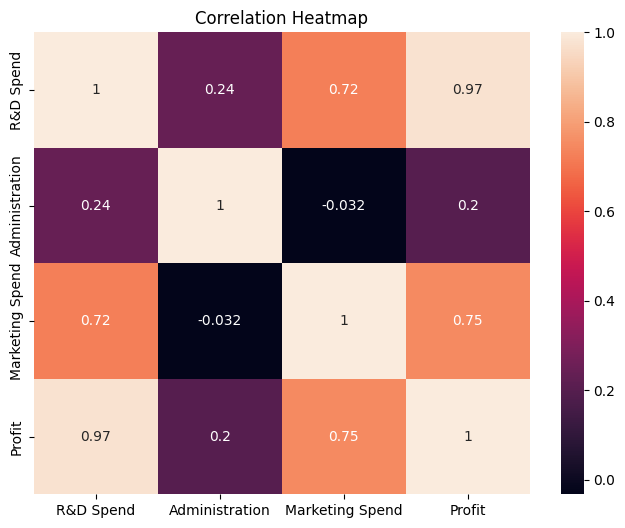

In [12]:
plt.figure(figsize=(8,6))

sns.heatmap(correlation, annot=True)

plt.title("Correlation Heatmap")
plt.show()

# Machine Learning — Linear Regression

Prepare the dataset and build a Linear Regression model to predict startup profit.

## 13. Encode Categorical Data

Convert the State column into numerical values.

In [13]:
df = pd.get_dummies(df, columns=["State"], drop_first=True)

df.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.30,136897.90,471784.20,192261.93,False,True
1,162597.80,151377.69,443898.63,191792.16,False,False
2,153441.61,101145.65,407934.64,191050.49,True,False
3,144372.51,118671.95,383199.72,182902.09,False,True
4,142107.44,91391.87,366168.52,166188.04,True,False


## 14. Separate Features and Target

Use the startup expenses as input features and Profit as the target.

In [14]:
X = df.drop("Profit", axis=1)
y = df["Profit"]

## 15. Split the Data

Split the dataset into training and testing data.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (40, 5)
Testing data: (10, 5)


## 16. Create the Linear Regression Model

Create a Linear Regression model.

In [16]:
model = LinearRegression()

## 17. Train the Model

Train the Linear Regression model using the training data.

In [17]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 18. Make Predictions

Use the trained model to predict profit for the test data.

In [18]:
y_pred = model.predict(X_test)

print(y_pred)

[126362.97908255  84608.55383634  99677.59425147  46357.56068582
 128750.58288504  50912.5174188  109741.45032702 100643.34281647
  97599.37574594 113097.52524432]


## 19. Model Evaluation

Evaluate the model using R² Score and Mean Squared Error.

In [19]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2 Score:", r2)
print("Mean Squared Error:", mse)

R2 Score: 0.8987266414328635
Mean Squared Error: 82010363.04430123


## 20. Actual vs Predicted Profit

Compare the actual profit values with the predicted values.

In [20]:
results = pd.DataFrame({
    "Actual Profit": y_test.values,
    "Predicted Profit": y_pred
})

results

,Actual Profit,Predicted Profit
0,134307.45,126362.979083
1,81005.86,84608.553836
2,99937.69,99677.594251
3,64926.18,46357.560686
4,125370.47,128750.582885
5,35673.51,50912.517419
6,105733.64,109741.450327
7,107404.44,100643.342816
8,97427.94,97599.375746
9,122776.96,113097.525244


## Conclusion

The 50 Startups dataset was analyzed using EDA techniques.  
Missing values and duplicate records were checked.  
Categorical data was converted into numerical form.  
The data was divided into training and testing sets.  
A Linear Regression model was trained and evaluated using R² Score and Mean Squared Error.